In [5]:
%load_ext autoreload
%autoreload 2

import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def read_in_data(data_dir):
    data_files = os.listdir(data_dir)
    print(data_files)
    run_data = []
    for data_file in data_files:
        with open(os.path.join(data_dir, data_file), encoding="utf-8") as file:
            metadata = data_file[:-4].split("_")
            print(metadata)
            if metadata[0][:3] != "exp":
                continue
            experiment_number = int(metadata[0][3:])
            number_runs = int(metadata[2])
            hadamard = len(metadata) == 4

            curr_data = np.zeros(number_runs)
            idx = 0
            for line in file.readlines():
                if "Error:" in line:
                    curr_data[idx] = float(line.split(" ")[2])
                    idx += 1
            
            run_data.append({
                "experiment_number": experiment_number,
                "number_runs": number_runs,
                "hadamard": hadamard,
                "data": curr_data
            })
    return run_data

def read_in_data_file(file_path):
    data_dir = os.path.join("rundata", "local")
    run_data = []
    with open(os.path.join(data_dir, file_path), encoding="utf-8") as file:
        curr_data = []
        experiment_number = 0
        number_runs = None
        hadamard = None

        for line in file:
            if "Index:" in line:
                # Process the previous experiment data if it exists
                if curr_data:
                    run_data.append({
                        "experiment_number": experiment_number + 1,
                        "number_runs": 512,
                        "hadamard": hadamard,
                        "data": np.array(curr_data)
                    })
                    curr_data = []
                continue

            if "Hadamard:" in line:
                hadamard = line.split(":")[1].strip().lower() == 'true'
                continue

            if "Experiment:" in line:
                experiment_number = int(line.split(":")[1].strip())
                continue

            # Process the error data lines
            if "Error:" in line:
                curr_data.append(float(line.split(" ")[2]))

        # Don't forget to add the last experiment's data
        if curr_data:
            run_data.append({
                "experiment_number": experiment_number + 1,
                "number_runs": number_runs,
                "hadamard": hadamard,
                "data": np.array(curr_data)
            })

    return run_data

exp_names = ['000, 001', '000, 110', '000, 111', '000, 010, 100', '000, 011, 100', '000, 011, 110', 'General Unitary']


def plot_combined_experiments(run_data, output_dir):
    # Prepare the data for the boxplot, only including 'No Hadamard' data
    no_hadamard_data = []
    experiment_labels = []
    
    # Filter and organize the data for plotting
    for run in run_data:
        if run['hadamard'] or run['experiment_number'] == len(exp_names):  # Skip the Hadamard data
            continue
        
        # Include only 'No Hadamard' data
        no_hadamard_data.extend(run['data'])
        experiment_labels.extend([exp_names[run['experiment_number'] - 1]] * len(run['data']))

    # Create a DataFrame for Seaborn
    df = pd.DataFrame({
        'Error Percentage': no_hadamard_data,
        'Experiment': experiment_labels
    })

    # Plotting
    plt.figure(figsize=(7,7))
    sns.boxplot(x='Experiment', y='Error Percentage', data=df)

    # Set the y-axis limits
    plt.ylim(0, 4)

    # Add a title
    plt.title('Experiment Results')

    # Improve the layout and save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'Combined_Experiments_Boxplot_No_Hadamard.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    

def plot_experiments(run_data, output_dir):
    # Group data by experiment number

    plt.rcParams['lines.linewidth'] = 20  # Sets the line width
    
    grouped_data = {}
    for run in run_data:
        exp_num = run['experiment_number']
        key = (exp_num, run['hadamard'])
        if key not in grouped_data:
            grouped_data[key] = []
        grouped_data[key].extend(run['data'])

        # Create box and whisker plots
    for exp_num in set(key[0] for key in grouped_data):
        hadamard_data = grouped_data.get((exp_num, True), [])
        no_hadamard_data = grouped_data.get((exp_num, False), [])

        data_to_plot = []
        labels = []

        if hadamard_data:
            data_to_plot.append(hadamard_data)
            labels.append('Randomized')

        if no_hadamard_data:
            data_to_plot.append(no_hadamard_data)
            labels.append('Unrandomized')

        if not data_to_plot:  # Skip if no data is available
            continue

        plt.figure(figsize=(4, 4))
        plt.boxplot(data_to_plot, labels=labels, widths=0.4)
        plt.ylabel('Error Percentage')
        plt.ylim(0, 5) if no_hadamard_data[0] < 10 else plt.ylim(0, 100)
        if (hadamard_data is not None) ^ (no_hadamard_data is not None):
            plt.title(f'{exp_names[exp_num - 1]}')
        else:
            plt.title(f'{exp_names[exp_num - 1]}')
        plt.savefig(os.path.join(output_dir, f'Experiment_{exp_num}_Comparison.png'), bbox_inches='tight')
        plt.close()

In [15]:
run_data = read_in_data(data_dir=os.path.join("final_run_data"))
output_dir = "charts"
plot_combined_experiments(run_data, output_dir)

['experiment_19_simulator.txt', 'experiment_17_simulator.txt', 'experiment_22_simulator.txt', 'experiment_5_simulator.txt', 'experiment_9_simulator.txt', 'experiment_2_simulator.txt', 'experiment_8_simulator.txt', 'experiment_11_simulator.txt', 'experiment_18_simulator.txt', 'experiment_23_simulator.txt', 'experiment_12_simulator.txt', 'experiment_6_simulator.txt', 'experiment_16_simulator.txt', 'experiment_4_simulator.txt', 'experiment_7_simulator.txt', 'experiment_20_simulator.txt', 'experiment_3_simulator.txt', 'experiment_15_simulator.txt', 'experiment_10_simulator.txt', 'experiment_0_simulator.txt', 'experiment_21_simulator.txt', 'experiment_1_simulator.txt', 'experiment_14_simulator.txt']


ValueError: invalid literal for int() with base 10: 'simulator'

In [8]:
run_data = read_in_data()
output_dir = os.path.join("rundata", "charts")
plot_experiments(run_data, output_dir)

TypeError: read_in_data() missing 1 required positional argument: 'data_dir'

In [3]:
import pstats
p = pstats.Stats('profile')
p.sort_stats('cumulative').print_stats(100)

Fri Feb 23 16:38:11 2024    profile

         9223419 function calls (9058471 primitive calls) in 36.871 seconds

   Ordered by: cumulative time
   List reduced from 11545 to 100 due to restriction <100>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   2681/1    0.029    0.000   36.889   36.889 {built-in method builtins.exec}
        1    0.000    0.000   36.889   36.889 experiment.py:1(<module>)
        1    0.000    0.000   18.095   18.095 experiment.py:99(run)
        1    0.000    0.000   18.007   18.007 C:\Users\kevin\Research\tomography-repo\pure_state_tomography.py:49(pure_state_tomography)
        8    0.001    0.000   18.000    2.250 C:\Users\kevin\Research\tomography-repo\measurement_manager.py:716(measure_state)
        8    0.002    0.000   17.997    2.250 C:\Users\kevin\Research\tomography-repo\qutils.py:138(run_circuit)
       12    0.000    0.000   17.503    1.459 C:\Users\kevin\AppData\Local\Programs\Python\Python310\lib\threading.py:288(wait)

plot paper plots

In [30]:
import os
import glob
import re

def parse_data_file(filename):
    """Parse a single results file, extracting header info and numeric data."""
    with open(filename, 'r') as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    index_val = None
    hadamard_val = None
    experiment_val = None
    data_points = []

    for line in lines:
        # Parse known header fields
        if line.startswith("Index:"):
            index_val = int(line.split(":", 1)[1].strip())
        elif line.startswith("Hadamard:"):
            hadamard_str = line.split(":", 1)[1].strip()
            hadamard_val = (hadamard_str.lower() == 'true')
        elif line.startswith("Experiment:"):
            experiment_val = int(line.split(":", 1)[1].strip())
        elif line.startswith("Fidelity:"):
            fidelity_val = float(line.split(":", 1)[1].strip())
            data_points.append(1 - fidelity_val)

    return {
        'index': index_val,
        'hadamard': hadamard_val,
        'experiment_number': experiment_val,
        'data': data_points
    }

def load_run_data(directory):
    """Load and parse all experiment files from a given directory."""
    run_data = []
    for filename in glob.glob(os.path.join(directory, '*.txt')):
        info = parse_data_file(filename)
        # Only add if we successfully parsed an experiment number
        if info['experiment_number'] is not None:
            run_data.append(info)
    return run_data


In [31]:
rd = load_run_data("final_run_data")

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distributions(run_data, output_dir='.'):
    """
    Creates two distribution plots:
      1) Experiments 0, 1, 2
      2) Experiments 3, 4, 5
    distinguishing Hadamard = True/False.
    Skips experiment 6 entirely.
    """

    # Convert run_data into a DataFrame
    rows = []
    for run in run_data:
        if run['experiment_number'] == 6:
            # Skip experiment 6
            continue
        for val in run['data']:
            rows.append({
                'Experiment': run['experiment_number'],
                'Hadamard': 'True' if run['hadamard'] else 'False',
                'Value': val
            })
    df = pd.DataFrame(rows)

    # --- 1) Plot for experiments [0, 1, 2] ---
    df_012 = df[df['Experiment'].isin([0, 1, 2])]
    if not df_012.empty:
        g1 = sns.displot(
            data=df_012,
            x="Value",
            hue="Hadamard",
            col="Experiment",     # Facet each experiment in a separate subplot
            col_wrap=3,          # Wrap columns for up to 3 subplots in a row
            kind="ecdf",         # Could also use "kde" if you prefer
            height=4, aspect=1.2 # Adjust figure size
        )
        g1.set_titles("Experiment {col_name}")
        plt.suptitle("Distributions: Experiments 0, 1, 2", y=1.05)
        plt.tight_layout()
        outpath_012 = f"{output_dir}/displot_experiments_0_1_2.png"
        plt.savefig(outpath_012, dpi=300)
        plt.close()
        print(f"Saved {outpath_012}")

    # --- 2) Plot for experiments [3, 4, 5] ---
    df_345 = df[df['Experiment'].isin([3, 4, 5])]
    if not df_345.empty:
        g2 = sns.displot(
            data=df_345,
            x="Value",
            hue="Hadamard",
            col="Experiment",
            col_wrap=3,
            kind="ecdf",
            height=4, aspect=1.2
        )
        g2.set_titles("Experiment {col_name}")
        plt.suptitle("Distributions: Experiments 3, 4, 5", y=1.05)
        plt.tight_layout()
        outpath_345 = f"{output_dir}/displot_experiments_3_4_5.png"
        plt.savefig(outpath_345, dpi=300)
        plt.close()
        print(f"Saved {outpath_345}")


In [33]:
plot_distributions(rd, output_dir="plots")

Saved plots/displot_experiments_0_1_2.png
Saved plots/displot_experiments_3_4_5.png


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distributions(run_data, output_dir='.'):
    """
    Creates distribution plots for experiments 0-2 and 3-5 with log x-axis,
    and combined ECDF plots for each group on the same plot.
    """
    
    # Convert run_data into a DataFrame
    rows = []
    for run in run_data:
        if run['experiment_number'] == 6:
            continue
        for val in run['data']:
            rows.append({
                'Experiment': run['experiment_number'],
                'Hadamard': 'True' if run['hadamard'] else 'False',
                'Value': val
            })
    df = pd.DataFrame(rows)

    # --- 1) Facet plots for experiments [0, 1, 2] ---
    df_012 = df[df['Experiment'].isin([0, 1, 2])]
    if not df_012.empty:
        g1 = sns.displot(
            data=df_012,
            x="Value",
            hue="Hadamard",
            col="Experiment",
            col_wrap=3,
            kind="ecdf",
            height=4, aspect=1.2
        )
        g1.set(xscale='log')  # Log scale
        g1.set_titles("Experiment {col_name}")
        plt.suptitle("Distributions: Experiments 0, 1, 2 (Log Scale)", y=1.05)
        plt.tight_layout()
        outpath_012 = f"{output_dir}/displot_experiments_0_1_2.png"
        plt.savefig(outpath_012, dpi=300)
        plt.close()
        print(f"Saved {outpath_012}")

    # --- 2) Facet plots for experiments [3, 4, 5] ---
    df_345 = df[df['Experiment'].isin([3, 4, 5])]
    if not df_345.empty:
        g2 = sns.displot(
            data=df_345,
            x="Value",
            hue="Hadamard",
            col="Experiment",
            col_wrap=3,
            kind="ecdf",
            height=4, aspect=1.2
        )
        g2.set(xscale='log')  # Log scale
        g2.set_titles("Experiment {col_name}")
        plt.suptitle("Distributions: Experiments 3, 4, 5 (Log Scale)", y=1.05)
        plt.tight_layout()
        outpath_345 = f"{output_dir}/displot_experiments_3_4_5.png"
        plt.savefig(outpath_345, dpi=300)
        plt.close()
        print(f"Saved {outpath_345}")
        
    df_789 = df[df['Experiment'].isin([7, 8, 9])]
    if not df_789.empty:
        g3 = sns.displot(
            data=df_789,
            x="Value",
            hue="Hadamard",
            col="Experiment",
            col_wrap=3,
            kind="ecdf",
            height=4, aspect=1.2
        )
        g3.set(xscale='log')  # Log scale
        g3.set_titles("Experiment {col_name}")
        plt.suptitle("Distributions: Experiments 7, 8, 9 (Log Scale)", y=1.05)
        plt.tight_layout()
        outpath_789 = f"{output_dir}/displot_experiments_7_8_9.png"
        plt.savefig(outpath_789, dpi=300)
        plt.close()
        print(f"Saved {outpath_789}")

plot_distributions(rd, output_dir="plots")

Saved plots/displot_experiments_0_1_2.png
Saved plots/displot_experiments_3_4_5.png
Saved plots/displot_experiments_7_8_9.png


Saved ECDF plot to plots


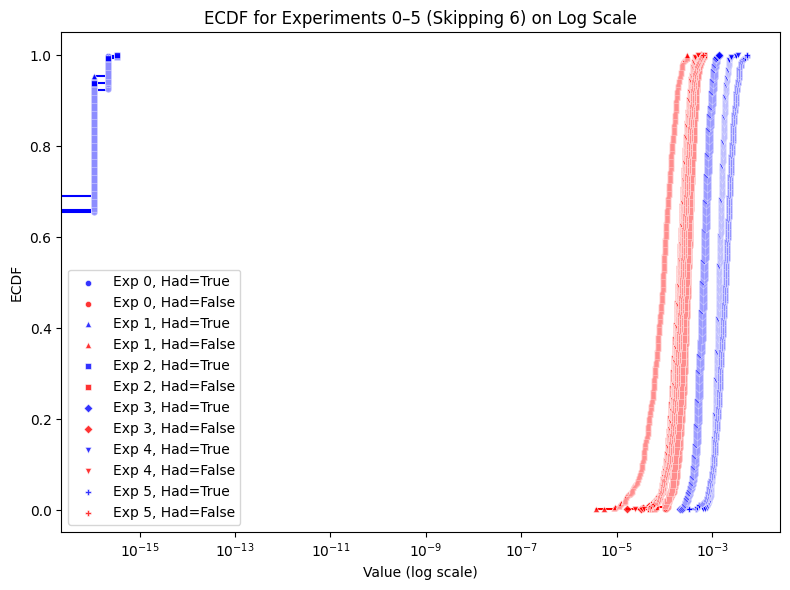

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf_all_together_logscale(run_data, output_path=None):
    """
    Plot a single ECDF figure for experiments 0–5 (skipping experiment 6)
    on a logarithmic x-axis.
    
    Each (experiment, hadamard) pair is plotted as a step function with markers.
    Unique marker shapes differentiate experiments and colors differentiate
    Hadamard (True vs. False).
    
    Parameters
    ----------
    run_data : list of dict
        Each dict should contain:
            - 'experiment_number': int
            - 'hadamard': bool
            - 'data': list of float (assumed to be positive for log scaling)
    output_path : str, optional
        If provided, the figure is saved to this path.
    """
    # Collect data into rows (skipping experiment 6)
    rows = []
    for run in run_data:
        exp_num = run['experiment_number']
        if exp_num == 6:
            continue
        for val in run['data']:
            rows.append({
                'Experiment': exp_num,
                'Hadamard': run['hadamard'],
                'Value': val
            })

    # Define marker shapes for experiments 0-5
    shape_map = {
        0: 'o',
        1: '^',
        2: 's',
        3: 'D',
        4: 'v',
        5: 'P'
    }
    # Define colors for Hadamard conditions
    color_map = {
        True: 'blue',
        False: 'red'
    }

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Loop over experiments and Hadamard conditions
    for exp in range(6):  # experiments 0 to 5
        for had in [True, False]:
            # Filter values for the current combination
            subset = [row['Value'] for row in rows 
                      if row['Experiment'] == exp and row['Hadamard'] == had]
            if not subset:
                continue  # Skip if no data exists for this combo
            
            # Compute the ECDF
            x_sorted = np.sort(subset)
            n = len(x_sorted)
            y = np.arange(1, n + 1) / n  # ECDF values
            
            # Use a unique marker shape for the experiment
            marker_shape = shape_map.get(exp, 'o')
            # Use color based on the Hadamard value
            color = color_map[had]
            
            label_str = f"Exp {exp}, Had={had}"
            
            # Plot the step function
            ax.step(x_sorted, y, where='post', color=color, linewidth=1.5)
            
            # Overlay markers (optionally, you may reduce number of markers if needed)
            markevery = max(1, n // 20)  # show a marker every ~20 points
            ax.scatter(x_sorted, y,
                       marker=marker_shape,
                       color=color,
                       s=20,
                       label=label_str,
                       zorder=3,
                       edgecolor='white',
                       linewidth=0.5,
                       alpha=0.8)
    
    # Set the x-axis to logarithmic scale
    ax.set_xscale('log')
    ax.set_xlabel("Value (log scale)")
    ax.set_ylabel("ECDF")
    ax.set_title("ECDF for Experiments 0–5 (Skipping 6) on Log Scale")
    
    # Consolidate duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='best')
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300)
        print(f"Saved ECDF plot to {output_path}")
    plt.show()
    plt.close(fig)


plot_ecdf_all_together_logscale(rd, "plots")

Saved ECDF groups plot to ecdf_groups_enlarged


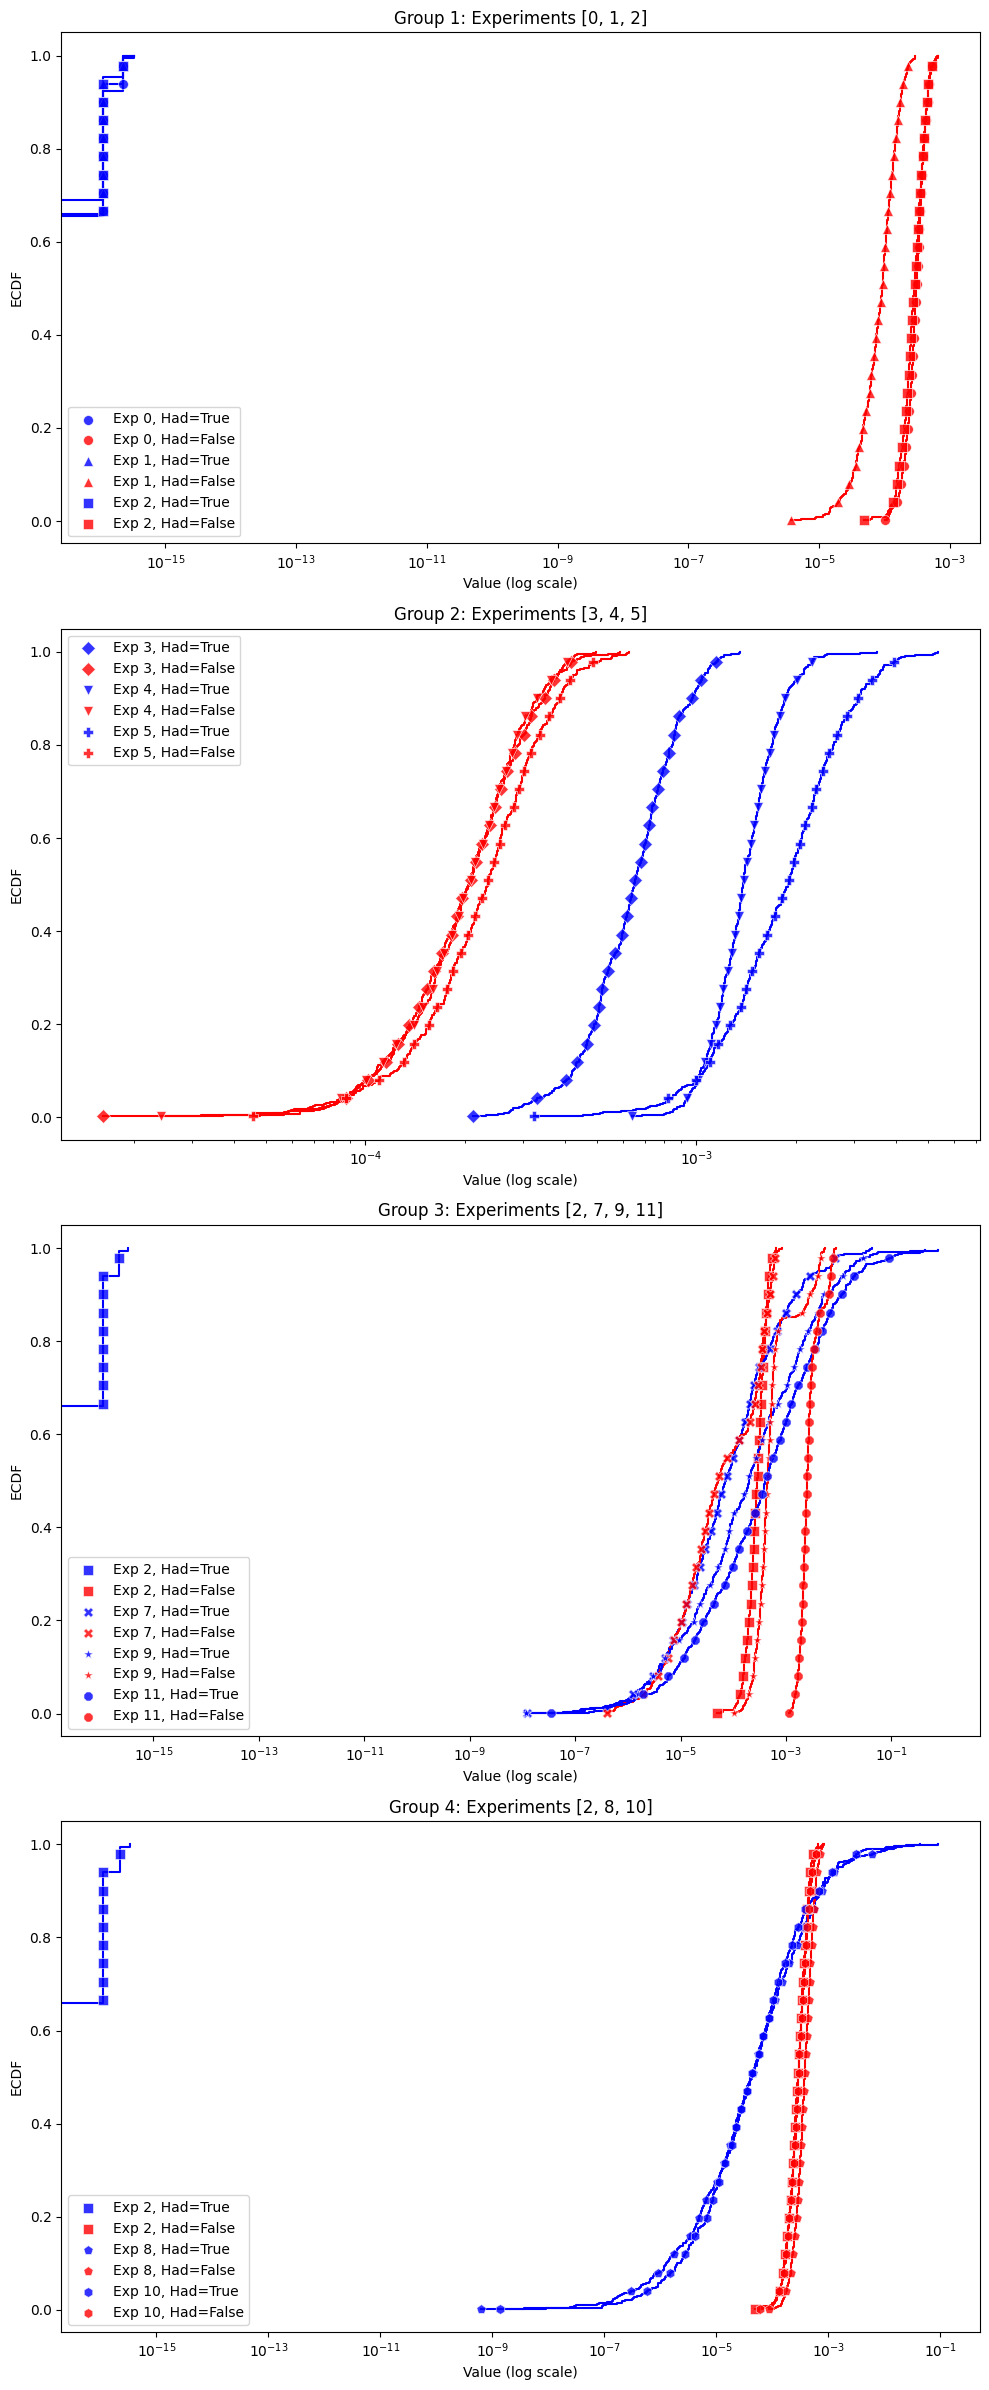

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf_groups(run_data, groups, output_path=None):
    """
    Plot ECDFs for multiple groups of experiments on separate subplots.
    
    Parameters
    ----------
    run_data : list of dict
        Each dict should contain:
            - 'experiment_number': int
            - 'hadamard': bool
            - 'data': list of float (assumed positive for log scale)
    groups : list of lists
        Each inner list contains the experiment numbers for that group.
        Example: [[0,1,2], [3,4,5], [2,7,9,11], [2,8,10]]
    output_path : str, optional
        If provided, saves the figure to this path.
    """
    # Build a list of rows for easier filtering (skip experiment 6)
    rows = []
    for run in run_data:
        exp_num = run['experiment_number']
        if exp_num == 6:
            continue
        for val in run['data']:
            rows.append({
                'Experiment': exp_num,
                'Hadamard': run['hadamard'],
                'Value': val
            })

    # Define marker shapes for experiments (add more if needed)
    shape_map = {
        0: 'o',
        1: '^',
        2: 's',
        3: 'D',
        4: 'v',
        5: 'P',
        7: 'X',
        8: 'p',
        9: '*',
        10: 'h',
        11: '8'
    }
    # Define colors for Hadamard conditions
    color_map = {True: 'blue', False: 'red'}

    n_groups = len(groups)
    # Increase the overall figure size to accommodate larger grouping
    fig, axes = plt.subplots(n_groups, 1, figsize=(10, 6 * n_groups), sharex=False)
    if n_groups == 1:
        axes = [axes]

    for idx, group in enumerate(groups):
        ax = axes[idx]
        ax.set_title(f"Group {idx + 1}: Experiments {group}")
        
        for exp in group:
            for had in [True, False]:
                # Filter the data for the current experiment and Hadamard condition.
                subset = [row['Value'] for row in rows 
                          if row['Experiment'] == exp and row['Hadamard'] == had]
                if not subset:
                    continue
                x_sorted = np.sort(subset)
                n = len(x_sorted)
                y = np.arange(1, n + 1) / n

                marker_shape = shape_map.get(exp, 'o')
                color = color_map[had]
                label_str = f"Exp {exp}, Had={had}"
                
                # Plot the ECDF as a step function.
                ax.step(x_sorted, y, where='post', color=color, linewidth=1.5)
                
                # Use fewer markers overall: plot only every n//50 point.
                markevery = max(1, n // 25)
                ax.scatter(x_sorted[::markevery], y[::markevery],
                           marker=marker_shape, color=color, s=50,
                           label=label_str, zorder=3, edgecolor='white', linewidth=0.5, alpha=0.8)
        
        ax.set_xscale('log')
        ax.set_xlabel("Value (log scale)")
        ax.set_ylabel("ECDF")
        
        # Consolidate duplicate legend entries.
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), loc='best')
    
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300)
        print(f"Saved ECDF groups plot to {output_path}")
    plt.show()
    plt.close(fig)

# Example usage:
# Define your groups: Group 1: [0,1,2], Group 2: [3,4,5], Group 3: [2,7,9,11], Group 4: [2,8,10]
groups = [
    [0, 1, 2],
    [3, 4, 5],
    [2, 7, 9, 11],
    [2, 8, 10]
]

# Assuming run_data is already defined with the proper structure, call:
plot_ecdf_groups(rd, groups, output_path="ecdf_groups_enlarged")


In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def build_df(run_data):
    """
    Convert run_data (list of dicts) into a DataFrame with columns:
      - 'FileID'      (unique identifier for each file)
      - 'Experiment'  (experiment_number)
      - 'Hadamard'    (True/False)
      - 'Value'       (each float in the data list)
    Skips experiment 6.
    """
    rows = []
    for i, run in enumerate(run_data):
        exp = run["experiment_number"]
        if exp == 6:
            continue  # skip experiment 6
        had = run["hadamard"]
        # Use an explicit filename if available; otherwise just use "File_<i>"
        file_id = run.get("filename", f"File_{i}")
        for val in run["data"]:
            rows.append({
                "FileID": file_id,
                "Experiment": exp,
                "Hadamard": had,
                "Value": val
            })
    return pd.DataFrame(rows)

def plot_boxplots_by_group(run_data, groups, output_dir="."):
    """
    For each group of experiments, create a box plot:
      - x-axis: each file (FileID)
      - y-axis: Value (log scale)
      - hue: Hadamard (True/False)
    Saves one PNG file per group in output_dir.
    """
    df = build_df(run_data)

    # Create a box plot for each group
    for idx, group_exps in enumerate(groups, start=1):
        # Filter rows to only those experiments in the current group
        df_group = df[df["Experiment"].isin(group_exps)]
        if df_group.empty:
            continue  # No data in this group, skip

        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=df_group,
            x="FileID",
            y="Value",
            hue="Hadamard",
            showfliers=True,    # or False to hide outliers
            notch=False         # or True if you like notched boxes
        )

        # Use log scale on the Y-axis
        plt.yscale("log")

        # Labeling
        plt.title(f"Group {idx}: Experiments {group_exps}")
        plt.xlabel("File (Data Set)")
        plt.ylabel("Value (log scale)")

        # Rotate x-labels if you have many files
        plt.xticks(rotation=45, ha="right")

        # Tidy up layout and save
        plt.tight_layout()
        outpath = os.path.join(output_dir, f"group_{idx}_boxplot.png")
        plt.savefig(outpath, dpi=300)
        print(f"Saved box plot for Group {idx} to {outpath}")
        plt.close()


In [47]:
groups = [
    [0, 1, 2],      # Group 1
    [3, 4, 5],      # Group 2
    [2, 7, 9, 11],  # Group 3
    [2, 8, 10]      # Group 4
]

plot_boxplots_by_group(rd, groups, output_dir="plots")

Saved box plot for Group 1 to plots/group_1_boxplot.png
Saved box plot for Group 2 to plots/group_2_boxplot.png
Saved box plot for Group 3 to plots/group_3_boxplot.png
Saved box plot for Group 4 to plots/group_4_boxplot.png
